# Notebook 01 — Data Loading & Cleaning
## IPL 2027 Franchise Squad Predictor

**Input files:**
- `data/raw/deliveries.csv` — 288,226 ball-by-ball records (2007–2026)
- `data/raw/matches.csv` — 1,212 match records

**Output:**
- `data/processed/deliveries_clean.parquet`
- `data/processed/matches_clean.parquet`

**What this notebook does:**
1. Loads both files safely
2. Fixes the mixed-type season column
3. Filters to the modern era (2016–2025 only)
4. Validates data quality
5. Saves clean parquets for Notebook 02

---

## Step 0 — Imports & Paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

RAW_DIR       = r"E:\My ML Projects\2027 cricket squad prediction\data\raw"
PROCESSED_DIR = r"E:\My ML Projects\2027 cricket squad prediction\data\processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Seasons to keep — modern IPL era only
# 2007: unofficial/ICL era, exclude
# 2026: incomplete season, exclude
# 2008-2015: older era, lower signal for 2027 prediction
# We keep 2016-2025: 10 full seasons, strong signal
TRAIN_SEASONS = list(range(2016, 2024))   # 2016-2023
TEST_SEASONS  = [2024, 2025]              # held out — never seen during training
KEEP_SEASONS  = TRAIN_SEASONS + TEST_SEASONS

print('Setup complete.')
print(f'Train seasons : {TRAIN_SEASONS}')
print(f'Test seasons  : {TEST_SEASONS}')

Setup complete.
Train seasons : [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Test seasons  : [2024, 2025]


## Step 1 — Load Raw Files

In [2]:
# low_memory=False prevents the mixed-type season column warning
deliveries = pd.read_csv(RAW_DIR + '\ipl_ball_by_ball_clean.csv', low_memory=False)
matches    = pd.read_csv(RAW_DIR + '\ipl_matches_clean.csv')

print(f'Deliveries raw shape : {deliveries.shape}')
print(f'Matches raw shape    : {matches.shape}')

Deliveries raw shape : (288226, 50)
Matches raw shape    : (1212, 14)


In [3]:
print('=== DELIVERIES COLUMNS (50 total) ===')
for i, col in enumerate(deliveries.columns):
    print(f'  {i+1:2d}. {col}')

=== DELIVERIES COLUMNS (50 total) ===
   1. match_id
   2. date
   3. season
   4. city
   5. venue
   6. team1
   7. team2
   8. batting_team
   9. bowling_team
  10. innings
  11. over
  12. ball_in_over
  13. legal_ball
  14. legal_ball_number
  15. over_ball_display
  16. batter
  17. bowler
  18. non_striker
  19. batter_runs
  20. extra_runs
  21. total_runs
  22. wides
  23. noballs
  24. byes
  25. legbyes
  26. penalty
  27. is_boundary_4
  28. is_boundary_6
  29. is_dot_ball
  30. is_wicket
  31. wicket_count
  32. wicket_player_out
  33. wicket_kind
  34. wicket_fielders
  35. innings_runs_so_far
  36. innings_wickets_so_far
  37. balls_remaining
  38. current_run_rate
  39. phase
  40. is_powerplay
  41. is_middle_overs
  42. is_death_overs
  43. toss_winner
  44. toss_decision
  45. match_winner
  46. batting_team_won
  47. target
  48. runs_required
  49. required_run_rate
  50. is_chasing


In [4]:
print('=== MATCHES COLUMNS ===')
print(matches.columns.tolist())
matches.head(3)

=== MATCHES COLUMNS ===
['match_id', 'date', 'season', 'city', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'player_of_match', 'match_type', 'overs', 'balls_per_over']


,match_id,date,season,city,venue,team1,team2,toss_winner,toss_decision,winner,player_of_match,match_type,overs,balls_per_over
0,1082591,05-04-2017,2017,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Sunrisers Hyderabad,Yuvraj Singh,T20,20,6
1,1082592,06-04-2017,2017,Pune,Maharashtra Cricket Association Stadium,Rising Pune Supergiant,Mumbai Indians,Rising Pune Supergiant,field,Rising Pune Supergiant,SPD Smith,T20,20,6
2,1082593,07-04-2017,2017,Rajkot,Saurashtra Cricket Association Stadium,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,Kolkata Knight Riders,CA Lynn,T20,20,6


## Step 2 — Fix Season Column

The `season` column has mixed types (some rows store it as int, some as string). We normalise to int.

In [5]:
deliveries['season'] = deliveries['season'].astype(str).str[:4].astype(int)
matches['season']    = matches['season'].astype(str).str[:4].astype(int)

print('All seasons in deliveries:', sorted(deliveries['season'].unique()))
print('All seasons in matches   :', sorted(matches['season'].unique()))

All seasons in deliveries: [2007, 2009, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
All seasons in matches   : [2007, 2009, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


## Step 3 — Standardise Team Names

Franchises get renamed over the years. We map everything to current names so historical performance aggregates correctly.

In [6]:
TEAM_MAP = {
    'Delhi Daredevils'          : 'Delhi Capitals',
    'Deccan Chargers'           : 'Sunrisers Hyderabad',
    'Kings XI Punjab'           : 'Punjab Kings',
    'Rising Pune Supergiants'   : 'Rising Pune Supergiant',
    'Pune Warriors'             : 'Pune Warriors India',
}

team_cols_del   = ['batting_team', 'bowling_team', 'team1', 'team2',
                   'toss_winner', 'match_winner']
team_cols_match = ['team1', 'team2', 'toss_winner', 'winner']

for col in team_cols_del:
    if col in deliveries.columns:
        deliveries[col] = deliveries[col].replace(TEAM_MAP)

for col in team_cols_match:
    if col in matches.columns:
        matches[col] = matches[col].replace(TEAM_MAP)

print('Team names standardised.')
print('Unique teams:', sorted(deliveries['batting_team'].unique()))

Team names standardised.
Unique teams: ['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors India', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


## Step 4 — Filter to Modern Era

**Why 2016 onwards?**
- T20 strategy has evolved significantly. 2016 saw the emergence of powerplay batting revolution.
- Player data from 2009–2015 has weaker signal for 2027 prediction.
- 2007: unofficial era data (ICL influence), exclude.
- 2026: incomplete season in progress, exclude.

In [7]:
del_clean   = deliveries[deliveries['season'].isin(KEEP_SEASONS)].copy()
match_clean = matches[matches['season'].isin(KEEP_SEASONS)].copy()

print(f'Deliveries after filter : {len(del_clean):,}  (was {len(deliveries):,})')
print(f'Matches after filter    : {len(match_clean):,}  (was {len(matches):,})')
print(f'Seasons kept            : {sorted(del_clean["season"].unique())}')

Deliveries after filter : 155,703  (was 288,226)
Matches after filter    : 652  (was 1,212)
Seasons kept            : [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


## Step 5 — Confirm Pre-Computed Columns

Your dataset already has these computed — we verify they are correct before trusting them.

In [8]:
print('=== PHASE VALUES ===')
print(del_clean['phase'].value_counts())

print('\n=== LEGAL BALL VALUES ===')
print(del_clean['legal_ball'].value_counts())

print('\n=== IS_DOT_BALL VALUES ===')
print(del_clean['is_dot_ball'].value_counts())

print('\n=== BATTING_TEAM_WON VALUES ===')
print(del_clean['batting_team_won'].value_counts())

print('\n=== IS_WICKET VALUES ===')
print(del_clean['is_wicket'].value_counts())

=== PHASE VALUES ===
phase
Middle       71401
Powerplay    48570
Death        35732
Name: count, dtype: int64

=== LEGAL BALL VALUES ===
legal_ball
1    149714
0      5989
Name: count, dtype: int64

=== IS_DOT_BALL VALUES ===
is_dot_ball
0    104030
1     51673
Name: count, dtype: int64

=== BATTING_TEAM_WON VALUES ===
batting_team_won
0    80868
1    74835
Name: count, dtype: int64

=== IS_WICKET VALUES ===
is_wicket
0    147956
1      7747
Name: count, dtype: int64


In [9]:
# Cross-check: phase vs over
# Powerplay = overs 0-5, Middle = 6-14, Death = 15-19
phase_check = del_clean.groupby('phase')['over'].agg(['min','max'])
print('Phase vs over range (should align with IPL phases):')
print(phase_check)

Phase vs over range (should align with IPL phases):
           min  max
phase              
Death       15   19
Middle       6   14
Powerplay    0    5


## Step 6 — Null Audit on Key Columns

In [10]:
KEY_COLS = [
    'match_id', 'season', 'batter', 'bowler',
    'batting_team', 'bowling_team',
    'batter_runs', 'is_wicket', 'is_dot_ball',
    'is_boundary_4', 'is_boundary_6',
    'legal_ball', 'phase',
    'batting_team_won', 'match_winner', 'venue'
]

print('=== NULL COUNTS ON KEY COLUMNS ===')
for col in KEY_COLS:
    nulls = del_clean[col].isnull().sum()
    status = '✓' if nulls == 0 else f'✗  {nulls} nulls'
    print(f'  {col:30s}: {status}')

=== NULL COUNTS ON KEY COLUMNS ===
  match_id                      : ✓
  season                        : ✓
  batter                        : ✓
  bowler                        : ✓
  batting_team                  : ✓
  bowling_team                  : ✓
  batter_runs                   : ✓
  is_wicket                     : ✓
  is_dot_ball                   : ✓
  is_boundary_4                 : ✓
  is_boundary_6                 : ✓
  legal_ball                    : ✓
  phase                         : ✓
  batting_team_won              : ✓
  match_winner                  : ✓
  venue                         : ✓


## Step 7 — Dataset Overview

In [11]:
print('=== DATASET SUMMARY ===')
print(f"Total deliveries     : {len(del_clean):,}")
print(f"Total matches        : {len(match_clean):,}")
print(f"Unique batters       : {del_clean['batter'].nunique()}")
print(f"Unique bowlers       : {del_clean['bowler'].nunique()}")
print(f"Unique venues        : {del_clean['venue'].nunique()}")
print(f"Seasons              : {sorted(del_clean['season'].unique())}")

matches_per_season = del_clean.groupby('season')['match_id'].nunique()
print(f"\nMatches per season:")
print(matches_per_season.to_string())

=== DATASET SUMMARY ===
Total deliveries     : 155,703
Total matches        : 652
Unique batters       : 439
Unique bowlers       : 347
Unique venues        : 40
Seasons              : [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

Matches per season:
season
2016    60
2017    59
2018    60
2019    60
2020    60
2021    60
2022    74
2023    74
2024    71
2025    74


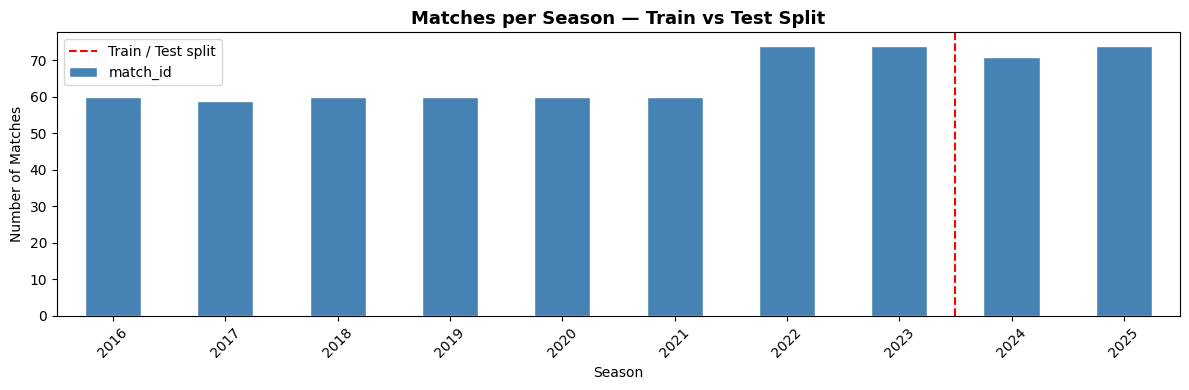

Plot saved.


In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
matches_per_season.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.axvline(x=list(matches_per_season.index).index(2024) - 0.5,
           color='red', linestyle='--', label='Train / Test split')
ax.set_title('Matches per Season — Train vs Test Split', fontsize=13, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Number of Matches')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/processed/matches_per_season.png', dpi=120)
plt.show()
print('Plot saved.')

## Step 8 — Save Clean Parquets

In [13]:
del_clean.to_parquet(PROCESSED_DIR + 'deliveries_clean.parquet', index=False)
match_clean.to_parquet(PROCESSED_DIR + 'matches_clean.parquet', index=False)

print('Saved:')
print(f'  deliveries_clean.parquet  — {len(del_clean):,} rows, {del_clean.shape[1]} columns')
print(f'  matches_clean.parquet     — {len(match_clean):,} rows, {match_clean.shape[1]} columns')

Saved:
  deliveries_clean.parquet  — 155,703 rows, 50 columns
  matches_clean.parquet     — 652 rows, 14 columns


## Step 9 — Final Validation Checks

Run this before moving to Notebook 02. All checks must pass.

In [14]:
df = pd.read_parquet(PROCESSED_DIR + 'deliveries_clean.parquet')

checks = [
    ('No null batters',         df['batter'].isnull().sum() == 0),
    ('No null bowlers',         df['bowler'].isnull().sum() == 0),
    ('No null batter_runs',     df['batter_runs'].isnull().sum() == 0),
    ('No null batting_team_won',df['batting_team_won'].isnull().sum() == 0),
    ('Phase has 3 values',      df['phase'].nunique() == 3),
    ('Season min is 2016',      df['season'].min() == 2016),
    ('Season max is 2025',      df['season'].max() == 2025),
    ('Rows > 150000',           len(df) > 150000),
    ('legal_ball is binary',    set(df['legal_ball'].unique()).issubset({0,1})),
]

all_pass = True
for name, result in checks:
    icon = '✓' if result else '✗  FAIL'
    print(f'{icon}  {name}')
    if not result:
        all_pass = False

print()
if all_pass:
    print('All checks passed. Proceed to Notebook 02.')
else:
    print('Fix failing checks before proceeding.')

✓  No null batters
✓  No null bowlers
✓  No null batter_runs
✓  No null batting_team_won
✓  Phase has 3 values
✓  Season min is 2016
✓  Season max is 2025
✓  Rows > 150000
✓  legal_ball is binary

All checks passed. Proceed to Notebook 02.
